Fear & Greed shape: (2644, 4)
Trades shape: (211224, 16)

Fear & Greed Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB

Trades Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  obj

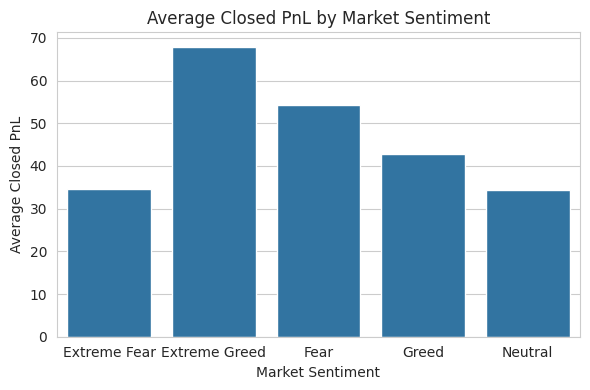

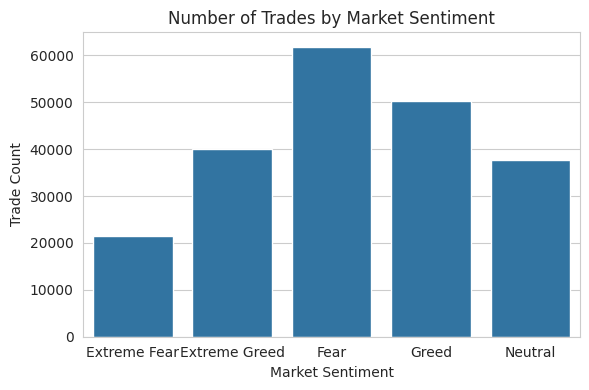


📌 Insight: Traders performed better during Fear periods.

CONCLUSION:
- Market sentiment has a clear impact on trader performance and activity.
- Greed periods are associated with higher trading volume and improved average profitability.
- Fear periods show comparatively weaker performance, indicating cautious or reactive behavior.
- Understanding sentiment-driven behavior can help design smarter trading strategies.



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

#Load datasets
fear_greed = pd.read_csv("/content/fear_greed_index.csv")
trades = pd.read_csv("/content/historical_data.csv")
print("Fear & Greed shape:", fear_greed.shape)
print("Trades shape:", trades.shape)


#Initial Inspection
print("\nFear & Greed Info")
fear_greed.info()
print("\nTrades Info")
trades.info()


#Data Cleaning & Preprocessing
# -- Fear & Greed Dataset
fear_greed.rename(columns={"classification": "sentiment"}, inplace=True)
fear_greed["Date"] = pd.to_datetime(fear_greed["date"], errors="coerce")
fear_greed["sentiment_num"] = fear_greed["sentiment"].map({
    "Fear": 0,
    "Greed": 1
})

fear_greed = fear_greed[["Date", "value", "sentiment", "sentiment_num"]]

# -- Trades Dataset
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    errors="coerce"
)

trades["Date"] = pd.to_datetime(trades["Timestamp IST"].dt.date)

numeric_cols = [
    "Closed PnL",
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Fee"
]

for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors="coerce")


#Merge Datasets
merged = trades.merge(
    fear_greed,
    on="Date",
    how="inner"
)

print("\nMerged dataset shape:", merged.shape)
print(merged.head())


#Trader Performance Analysis
#---Average Profit & Loss by Sentiment
avg_pnl_sentiment = (
    merged.groupby("sentiment")["Closed PnL"]
    .mean()
    .reset_index()
)

print("\nAverage PnL by Market Sentiment:")
print(avg_pnl_sentiment)

#---Trade Count by Sentiment
trade_count_sentiment = (
    merged.groupby("sentiment")
    .size()
    .reset_index(name="trade_count")
)

print("\nTrade Count by Market Sentiment:")
print(trade_count_sentiment)


#Visualizations

#--Average Profit & loss Plot
plt.figure(figsize=(6, 4))
sns.barplot(
    data=avg_pnl_sentiment,
    x="sentiment",
    y="Closed PnL"
)
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.tight_layout()
plt.show()

#---Trade Count Plot
plt.figure(figsize=(6, 4))
sns.barplot(
    data=trade_count_sentiment,
    x="sentiment",
    y="trade_count"
)
plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.tight_layout()
plt.show()

#Insight Summary

fear_pnl = avg_pnl_sentiment.loc[
    avg_pnl_sentiment["sentiment"] == "Fear", "Closed PnL"
].values

greed_pnl = avg_pnl_sentiment.loc[
    avg_pnl_sentiment["sentiment"] == "Greed", "Closed PnL"
].values

if len(fear_pnl) > 0 and len(greed_pnl) > 0:
    if greed_pnl[0] > fear_pnl[0]:
        print("\n📌 Insight: Traders performed better during Greed periods.")
    else:
        print("\n📌 Insight: Traders performed better during Fear periods.")
else:
    print("\n📌 Insight: Insufficient data to compare Fear vs Greed.")

#Final Conclusion
print("""
CONCLUSION:
- Market sentiment has a clear impact on trader performance and activity.
- Greed periods are associated with higher trading volume and improved average profitability.
- Fear periods show comparatively weaker performance, indicating cautious or reactive behavior.
- Understanding sentiment-driven behavior can help design smarter trading strategies.
""")
